# Objectives: Cheapen Costs & Reduce Bulk Buy Frequency
1. Cheapen cost for raw materials (e.g., raw metals)
2. Buy more raw materials less frequently
     - Give clients a workable time interval to monitor bulk prices & buy at a "low"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

In [2]:
CharmsPendantsClasps = pd.read_csv('/work/CharmsPendantsClasps.csv', encoding = 'latin-1')
materiallist = pd.read_csv('/work/MaterialCabochon.csv', encoding = 'latin-1')
materialexpense = pd.read_csv('/work/MaterialExpense.csv', encoding = 'latin-1') 
df = pd.read_csv('/work/MaterialExpense.csv', encoding = 'latin-1') #for test
sales = pd.read_csv('/work/TotalSales.csv', encoding = 'latin-1')

In [3]:
CharmsPendantsClasps.head()

,Item #,Type,Inventory Name,Variant,Metal,Cost / Charm,Labor,Jump Ring,Total Cost,W/S Markup,...,Retail Rounded Price,Retail Profit,Proposed Pricing,Current Website Pricing,Current H/(L) than Proposed,Unnamed: 21,Jump Ring Metal,Jump Ring Size and Gauge,Assumes 1 free reweld; 2 jump rings at highest bulk pricing,Rio
0,S631CZ,Lighting Bolt,Sterling Silver Pave CZ Tiny Lightning Charm,NaN,SS,1.25,$0.00,$0.29,1.5374,1.0,...,6,4,6,8,2,NaN,Gold,2.4m 24 G,3.80,650411.0
1,ST595CZ,Dragonfly,Sterling Silver CZ Dragonfly Pendant,NaN,SS,3.52,$0.00,$0.29,3.8074,1.0,...,10,6,10,8,(2),NaN,Gold,2.4m 24 G,3.80,650411.0
2,GF2465T2,Bar Blanks,Gold-Filled 21 gauge Link Bar Blanks\r\n\r\n,NaN,GF,8.83,0,$7.86,16.69,1.0,...,46,29,46,20,(26),NaN,Gold,3.2m 22 G,7.86,924866.0
3,GF2465HT2,Bar Necklace Pendant Blanks,Gold-Filled 21 gauge Bar Necklace Pendant Blanks,NaN,GF,8.79,0,$7.86,16.65,1.0,...,46,29,46,20,(26),NaN,Gold,2.4m 22 G,6.23,640236.0
4,698469,Bezel Cup,COMP SS 10X8MM OVAL BEZEL 1-RNG,NaN,SS,$2.81,$0.00,$0.29,$3.09,1.0,...,10,7,10,8,(2),NaN,Gold,2.4m 24 G,3.80,650411.0


In [4]:
materiallist.head()

,Mine,Item #,Stone Name,Current Qty,Size/ Gage,Shape,Color,Cost,Quantity/PKG,#VALUE!,Unnamed: 10
0,NaN,NaN,Natural Lone Mountain Turquoise,7,varied,oval,blue,33,7.0,4.714285714,NaN
1,NaN,NaN,Paloma Variscite,10,varied,oval,green,48,10.0,4.8,NaN
2,NaN,NaN,Spiny Oyster,30,varied,square,pink,80.5,30.0,2.683333333,NaN
3,NaN,NaN,Turquoise Mix,33,varied,oval,blue,148.75,33.0,4.507575758,NaN
4,NaN,243581,Aurora Opal Cabochon,1,6 x3.6mm,Diamond,Orange,6.78,1.0,6.78,NaN


In [5]:
materialexpense.head()

,Date,OrderNumber,Total Order spend,ItemNumber,ItemDescription,Total Count,Quantity Order,Price/ Pkg,Quantity in PKG,Unit Price + SHIPPING,Unit,NOTES,Total Item Cost,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,4/28/2023,2869687586,$301,BU65CZ,Gold Filled (14KGF) 5.7 x 4.9mm Tiny Butterfly...,NaN,3.0,$5.00,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2023,2869687586,$301,ST76LETR2,Gold Filled (14KGF) 6 X 9mm Star Shape Letter ...,NaN,2.0,$2.78,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4/26/2023,2869687586,$301,AA01,Gold Filled (14KGF) 5.9mm Basic Letter Charm W...,NaN,1.0,$4.30,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4/25/2023,2869687586,$301,CZ84RD,Gold Filled (14KGF) 8.3 x 4.8mm Blank Disc wit...,NaN,3.0,$5.60,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4/24/2023,2869687586,$301,EY9335CZ,Gold Filled (14KGF) / 925 Silver 9.3 x 3.5mm E...,NaN,3.0,$4.28,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
CharmsPendantsClasps.isna().sum()

Item #                                                         164
Type                                                            45
Inventory Name                                                  39
Variant                                                        262
Metal                                                           39
Cost / Charm                                                    42
Labor                                                            0
Jump Ring                                                        0
Total Cost                                                       0
W/S Markup                                                       0
W/S Price                                                        2
W/S Rounded Price                                                0
Retail Markup                                                    0
Retail Pricing w/ Markup                                         0
Shipping                                                      

In [7]:
materialexpense.isna().sum()

Date                       12
OrderNumber                30
Total Order spend         233
ItemNumber                 91
ItemDescription             0
Total Count                53
Quantity Order            199
Price/ Pkg                  0
Quantity in PKG           132
Unit Price + SHIPPING       0
Unit                      183
NOTES                    2366
Total Item Cost          2314
Unnamed: 13              2400
Unnamed: 14              2400
Unnamed: 15              2400
Unnamed: 16              2400
Unnamed: 17              2400
dtype: int64

In [8]:
materiallist.isna().sum()

Mine            529
Item #          372
Stone Name       14
Current Qty     123
Size/ Gage      142
Shape            50
Color            95
Cost             22
Quantity/PKG     74
#VALUE!           0
Unnamed: 10     520
dtype: int64

In [9]:
df["Price/ Pkg"] = df["Price/ Pkg"].str.replace("$", "", regex=False).str.replace(",", "")
df = df[df["Price/ Pkg"] != "#DIV/0!"]  
df["Price/ Pkg"] = df["Price/ Pkg"].astype(float)

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y").dt.strftime("%m/%d/%Y")
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

df = df.sort_values("Date")

In [10]:
# clean
df.head()

,Date,OrderNumber,Total Order spend,ItemNumber,ItemDescription,Total Count,Quantity Order,Price/ Pkg,Quantity in PKG,Unit Price + SHIPPING,Unit,NOTES,Total Item Cost,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
2262,2016-04-07,2094510,NaN,632812B,SS Chain 5.9MM Cable FTG,60,5.0,10.89,12,$0.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2261,2017-12-03,72311407,$416,618838,Sterling Silver Hinged One-Piece Cuff Link Back,10,10.0,9.40,1,$9.40,PER PAIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260,2019-12-16,73436489,$824,692769,SETTING SS 6MM RND TUBE,8,4.0,10.95,2,$5.48,PER 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2259,2019-12-16,73436489,$824,692768,SETTING SS 5MM RND TUBE,10,5.0,8.98,2,$4.49,PER 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2258,2019-12-16,73436489,$824,692767,SETTING SS 4MM RND TUBE,14,7.0,8.34,2,$4.17,PER 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


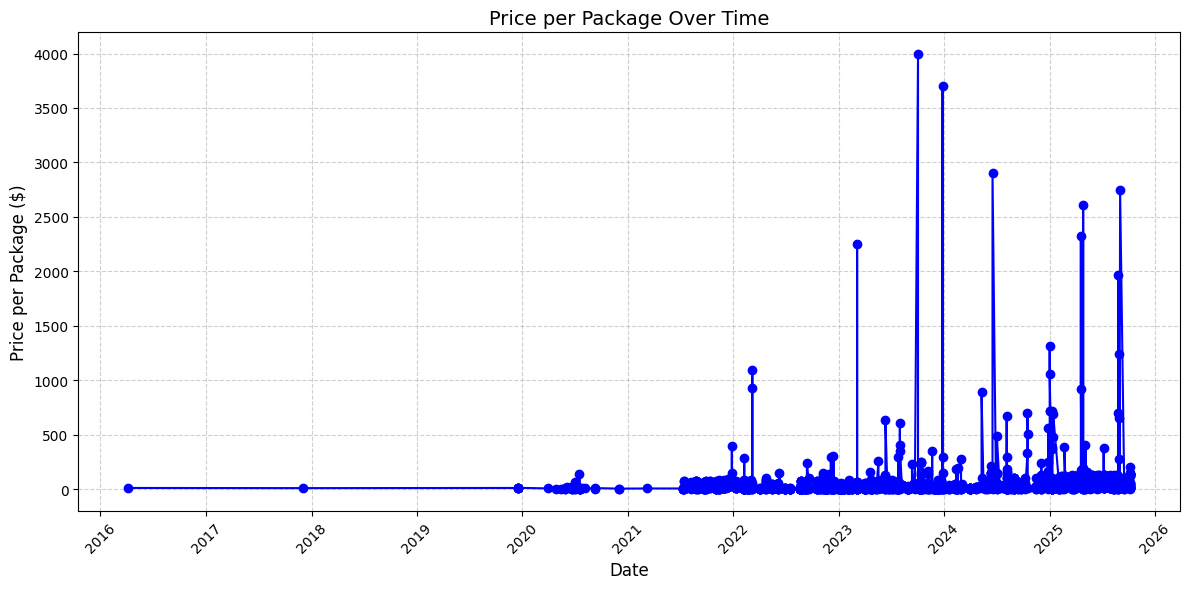

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Price/ Pkg"], marker="o", linestyle="-", color="b")
plt.title("Price per Package Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price per Package ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

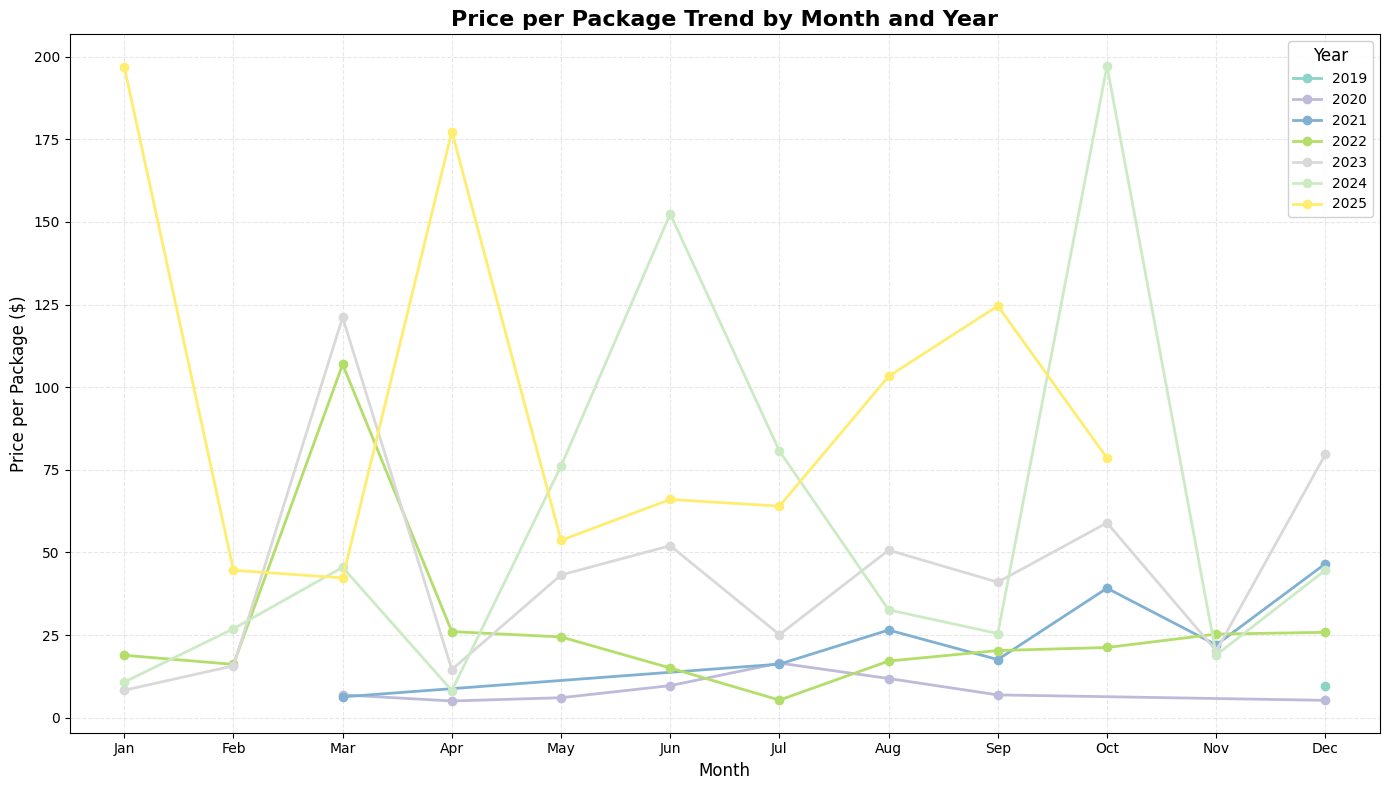


 Yearly Statistics:
       mean     std  count
Year                      
2019   9.61    2.10      5
2020  12.03   23.69     35
2021  26.27   38.66    179
2022  24.06   69.26    527
2023  36.81  217.14    765
2024  42.55  162.18    432
2025  84.79  250.67    496


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Assuming df is already loaded and cleaned
# Ensure 'Date' column is in datetime format
if df['Date'].dtype != 'datetime64[ns]':
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# Extract Year and Month from Date
# Drop rows with NaN in 'Date'
df = df.dropna(subset=['Date'])

# Extract Year and Month from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Year-Month'] = df['Date'].dt.to_period('M')

# Filter out specific years
df = df[~df['Year'].isin([2016, 2017])]

plt.figure(figsize=(14, 8))

years = df['Year'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    year_data = df[df['Year'] == year]
    
    monthly_avg = year_data.groupby('Month')['Price/ Pkg'].mean().reset_index()
    
    plt.plot(monthly_avg['Month'], monthly_avg['Price/ Pkg'], 
             marker='o', linestyle='-', linewidth=2, markersize=6,
             color=colors[i], label=f'{year}')

plt.xlim(0.5, 12.5)
plt.xticks(range(1, 13), 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.title('Price per Package Trend by Month and Year', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Price per Package ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(title='Year', title_fontsize=12, fontsize=10, 
           loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

print("\n Yearly Statistics:")
yearly_stats = df.groupby('Year')['Price/ Pkg'].agg(['mean', 'std', 'count']).round(2)
print(yearly_stats)

In [13]:
import plotly.express as px
import plotly.graph_objects as go

# --- Prep ---
df = df.dropna(subset=['Date']).copy()
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df = df[~df['Year'].isin([2016, 2017])]  # exclude 2016/2017

# Month label for nicer x-axis
df['MonthName'] = df['Date'].dt.month_name().str[:3]
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly averages per Year
monthly_avg = (
    df.groupby(['Year', 'Month', 'MonthName'], as_index=False)['Price/ Pkg']
      .mean()
      .rename(columns={'Price/ Pkg': 'Price per Pkg'})
)

# --- Line chart (interactive) ---
fig = px.line(
    monthly_avg,
    x='MonthName',
    y='Price per Pkg',
    color='Year',
    markers=True,
    color_discrete_sequence=px.colors.qualitative.Set3,
    title='Price per Package Trend by Month and Year'
)

fig.update_traces(
    line=dict(width=2.5),
    marker=dict(size=7),
    hovertemplate='Year: %{fullData.name}<br>Month: %{x}<br>Avg Price: $%{y:,.2f}<extra></extra>'
)

fig.update_layout(
    template='simple_white',
    xaxis=dict(title='Month', categoryorder='array', categoryarray=month_order),
    yaxis=dict(title='Price per Package ($)'),
    legend_title_text='Year',
    height=600
)

fig.show()

# --- Yearly stats table (optional, Plotly Table) ---
yearly_stats = (
    df.groupby('Year')['Price/ Pkg']
      .agg(mean='mean', std='std', count='count')
      .round(2)
      .reset_index()
)

table = go.Figure(
    data=[go.Table(
        header=dict(
            values=['Year', 'Mean ($)', 'Std Dev', 'Count'],
            fill_color='lightgrey',
            align='center'
        ),
        cells=dict(
            values=[yearly_stats['Year'],
                    yearly_stats['mean'],
                    yearly_stats['std'],
                    yearly_stats['count']],
            align='center'
        )
    )]
)
table.update_layout(title='Yearly Statistics', height=350)
table.show()


In [14]:
import plotly.graph_objects as go
import numpy as np

# Assume you already have 'monthly_avg' from before
# Columns: ['Year', 'Month', 'MonthName', 'Price per Pkg']
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Sort years
years = sorted(monthly_avg['Year'].unique())

# Custom gradient of blues (light → dark)
blue_palette = [
    "#CFE2F3",  # very light blue (oldest year)
    "#9FC5E8",
    "#6FA8DC",
    "#3D85C6",
    "#0B5394"   # navy / most recent
]

# If you have more or fewer years, interpolate to match automatically:
if len(years) > len(blue_palette):
    from matplotlib.colors import to_hex
    from matplotlib import cm
    cmap = cm.get_cmap("Blues")
    blue_palette = [to_hex(cmap(x)) for x in np.linspace(0.3, 0.9, len(years))]

# --- Create the figure ---
fig = go.Figure()

for i, year in enumerate(years):
    year_df = monthly_avg[monthly_avg['Year'] == year]
    fig.add_trace(
        go.Scatter(
            x=year_df['MonthName'],
            y=year_df['Price per Pkg'],
            mode='lines+markers',
            name=str(year),
            line=dict(color=blue_palette[i], width=3),
            marker=dict(size=7, color=blue_palette[i]),
            hovertemplate=f"Year: {year}<br>Month: %{{x}}<br>Avg Price: $%{{y:,.2f}}<extra></extra>"
        )
    )

# --- Layout ---
fig.update_layout(
    template='simple_white',
    title='Price per Package Trend by Month and Year',
    xaxis=dict(title='Month', categoryorder='array', categoryarray=month_order),
    yaxis_title='Price per Package ($)',
    paper_bgcolor='#EAEAEA',   # <— add here
    plot_bgcolor='#EAEAEA',     # <— add here
    legend_title_text='Year',
    legend_traceorder='normal',  # newest year appears last (darkest)
    height=600
)

fig.show()

In [15]:
top5_freq = df['ItemNumber'].value_counts().head(5)
print(top5_freq)

ItemNumber
650411                16
640236                12
633613B               12
107386                12
SHIPPING ESTIMATES    12
Name: count, dtype: int64


In [16]:
CharmsPendantsClasps['total cost']=CharmsPendantsClasps['Total Cost'].str.replace("$", "", regex=False).str.replace(",", "")
CharmsPendantsClasps['revenue']=CharmsPendantsClasps['Retail Rounded Price'].astype('int')
CharmsPendantsClasps['total cost']=CharmsPendantsClasps['total cost'].astype('float')

In [17]:
CharmsPendantsClasps['total cost'].head(20)

0      1.5374
1      3.8074
2     16.6900
3     16.6500
4      3.0900
5      4.3400
6     12.2300
7     11.1100
8     13.5200
9      9.9400
10    10.1500
11    10.1500
12    11.1600
13    11.9900
14     3.4200
15    10.6300
16    10.6300
17    11.1600
18    10.6300
19    10.6300
Name: total cost, dtype: float64

In [18]:
sum_by_type = CharmsPendantsClasps.groupby(CharmsPendantsClasps['Metal'].str.strip().str.upper())[['Retail Profit', 'total cost', 'revenue']].sum().reset_index()
sum_by_type

,Metal,Retail Profit,total cost,revenue
0,10KW,126,80.080000,206
1,10KY,220,137.890000,358
2,14K,103,62.977400,166
3,14KW,77,49.050000,126
4,14KY,939,602.090000,1542
5,GF,4301,2472.215680,6776
6,RGF,73,38.042200,110
7,SS,1196,497.104033,1682


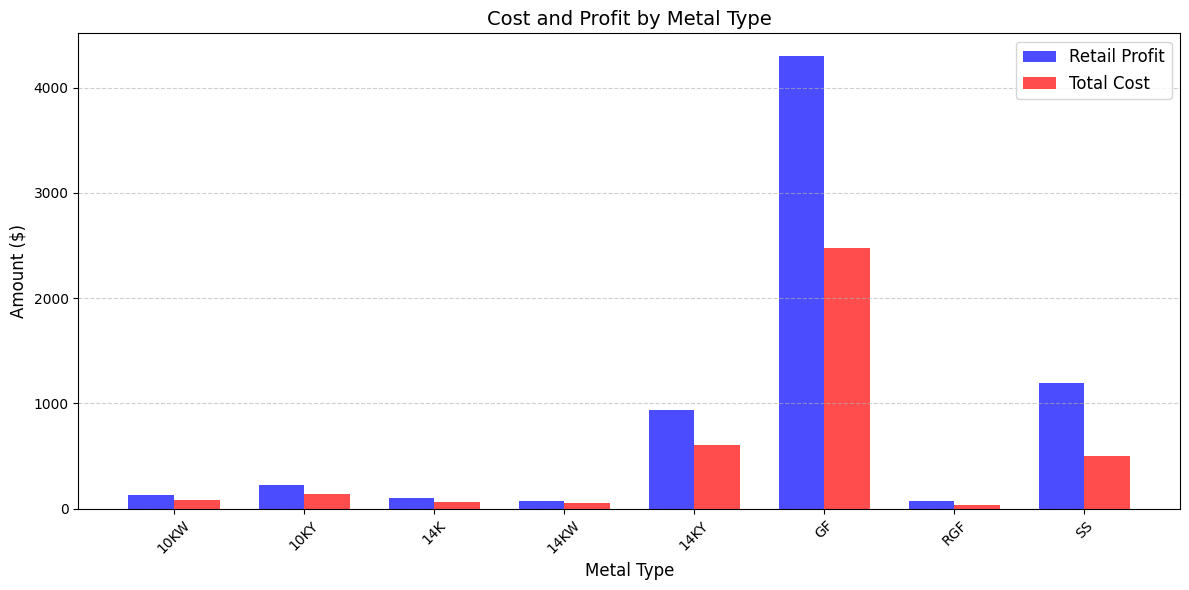

In [19]:
plt.figure(figsize=(12, 6))

bar_width = 0.35
index = range(len(sum_by_type["Metal"]))

plt.bar([i - bar_width/2 for i in index], sum_by_type["Retail Profit"], 
        width=bar_width, color='b', alpha=0.7, label='Retail Profit')

plt.bar([i + bar_width/2 for i in index], sum_by_type["total cost"], 
        width=bar_width, color='r', alpha=0.7, label='Total Cost')

plt.title("Cost and Profit by Metal Type", fontsize=14)
plt.xlabel("Metal Type", fontsize=12)
plt.ylabel("Amount ($)", fontsize=12)

plt.xticks(index, sum_by_type["Metal"], rotation=45)

plt.grid(True, linestyle="--", alpha=0.6, axis='y')
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

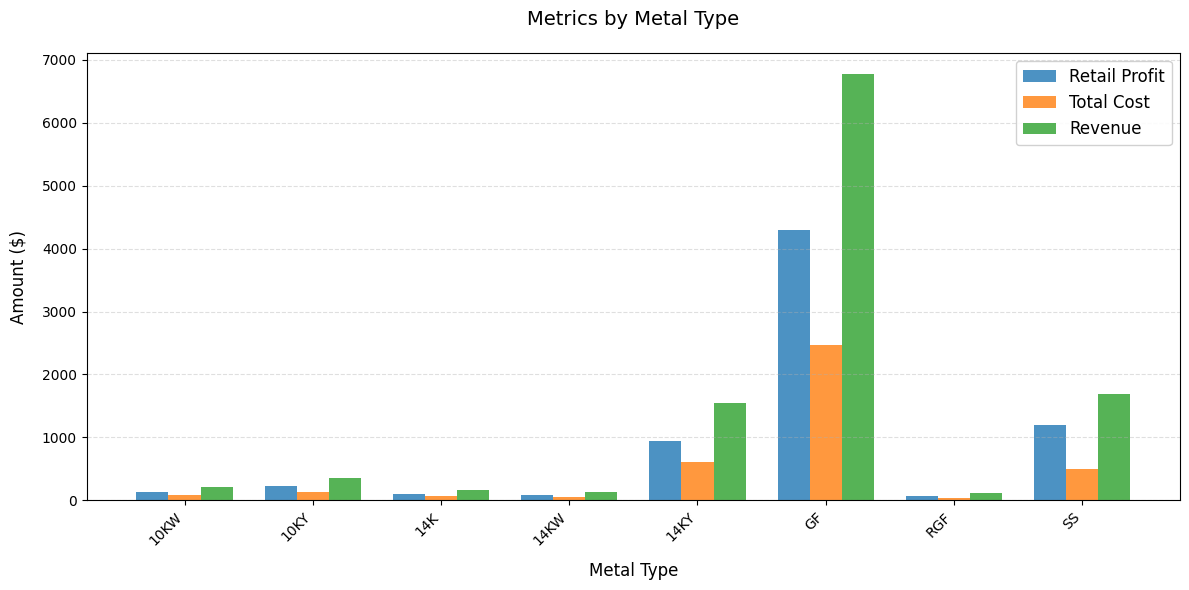

In [20]:
plt.figure(figsize=(12, 6))

bar_width = 0.25
index = range(len(sum_by_type["Metal"]))

plt.bar([i - bar_width for i in index], sum_by_type["Retail Profit"], 
        width=bar_width, color='#1f77b4', alpha=0.8, label='Retail Profit')

plt.bar(index, sum_by_type["total cost"], 
        width=bar_width, color='#ff7f0e', alpha=0.8, label='Total Cost')

plt.bar([i + bar_width for i in index], sum_by_type["revenue"], 
        width=bar_width, color='#2ca02c', alpha=0.8, label='Revenue')

plt.title("Metrics by Metal Type", fontsize=14, pad=20)
plt.xlabel("Metal Type", fontsize=12, labelpad=10)
plt.ylabel("Amount ($)", fontsize=12, labelpad=10)

plt.xticks(index, sum_by_type["Metal"], rotation=45, ha='right')

plt.grid(True, linestyle="--", alpha=0.4, axis='y')
plt.legend(fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

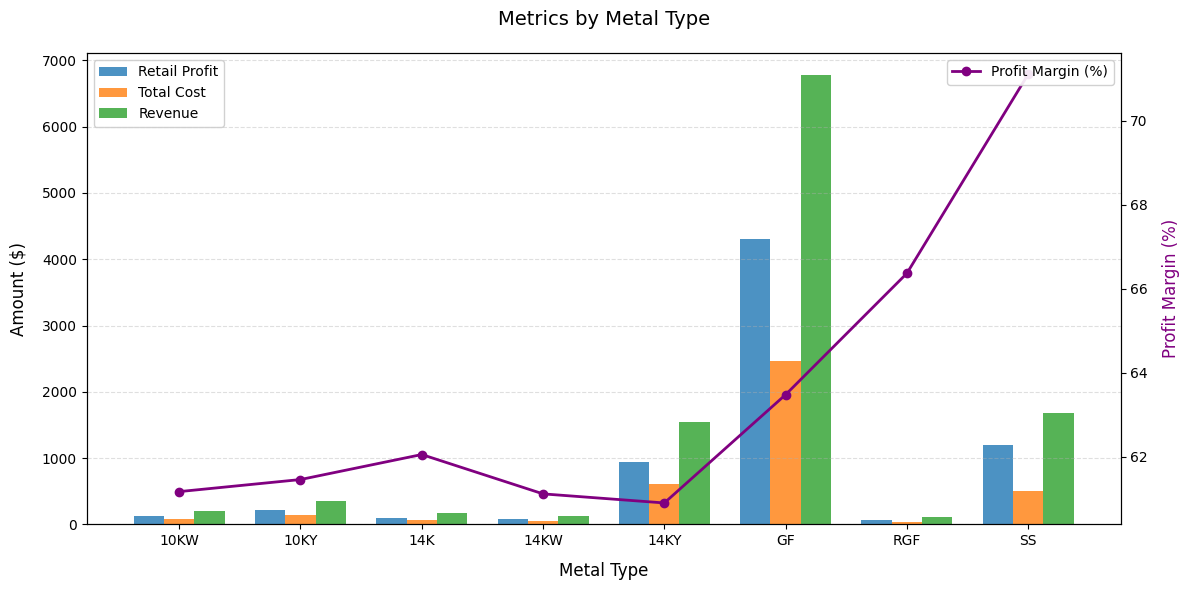

In [21]:
# profit rate
sum_by_type["Profit Margin (%)"] = (sum_by_type["Retail Profit"] / sum_by_type["revenue"] * 100).replace([np.inf, -np.inf], np.nan)

# setting
plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(sum_by_type["Metal"]))

# 3 bar
plt.bar(index - bar_width, sum_by_type["Retail Profit"], width=bar_width, color="#1f77b4", alpha=0.8, label="Retail Profit")
plt.bar(index, sum_by_type["total cost"], width=bar_width, color="#ff7f0e", alpha=0.8, label="Total Cost")
plt.bar(index + bar_width, sum_by_type["revenue"], width=bar_width, color="#2ca02c", alpha=0.8, label="Revenue")

# line
ax1 = plt.gca()
ax2 = ax1.twinx()  
ax2.plot(index, sum_by_type["Profit Margin (%)"], color="purple", marker="o", linewidth=2, label="Profit Margin (%)")

# title
ax1.set_title("Metrics by Metal Type", fontsize=14, pad=20)
ax1.set_xlabel("Metal Type", fontsize=12, labelpad=10)
ax1.set_ylabel("Amount ($)", fontsize=12, labelpad=10)
ax2.set_ylabel("Profit Margin (%)", fontsize=12, labelpad=10, color="purple")

plt.xticks(index, sum_by_type["Metal"], rotation=45, ha="right")

ax1.grid(True, linestyle="--", alpha=0.4, axis="y")
ax1.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax2.legend(loc="upper right", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Ensure profit margin exists (and handle inf)
sum_by_type["Profit Margin (%)"] = (
    (sum_by_type["Retail Profit"] / sum_by_type["revenue"]) * 100
).replace([np.inf, -np.inf], np.nan)

# If you want to preserve the current Metal order; otherwise sort as you like
x_cats = sum_by_type["Metal"].astype(str).tolist()

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Grouped bars (left y-axis)
fig.add_trace(
    go.Bar(
        name="Retail Profit",
        x=x_cats,
        y=sum_by_type["Retail Profit"],
        marker_color="#1f77b4",
        opacity=0.8,
        hovertemplate="Metal: %{x}<br>Retail Profit: $%{y:,.2f}<extra></extra>",
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Bar(
        name="Total Cost",
        x=x_cats,
        y=sum_by_type["total cost"],
        marker_color="#ff7f0e",
        opacity=0.8,
        hovertemplate="Metal: %{x}<br>Total Cost: $%{y:,.2f}<extra></extra>",
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Bar(
        name="Revenue",
        x=x_cats,
        y=sum_by_type["revenue"],
        marker_color="#2ca02c",
        opacity=0.8,
        hovertemplate="Metal: %{x}<br>Revenue: $%{y:,.2f}<extra></extra>",
    ),
    secondary_y=False,
)

# Profit margin line (right y-axis)
fig.add_trace(
    go.Scatter(
        name="Profit Margin (%)",
        x=x_cats,
        y=sum_by_type["Profit Margin (%)"],
        mode="lines+markers",
        marker=dict(size=8),
        line=dict(color="purple", width=2),
        hovertemplate="Metal: %{x}<br>Profit Margin: %{y:.1f}%<extra></extra>",
    ),
    secondary_y=True,
)

# Layout
fig.update_layout(
    title="Metrics by Metal Type",
    barmode="group",
    template="simple_white",
    height=600,
    legend_title_text="Metric",
    paper_bgcolor='#EAEAEA',   # <— add here
    plot_bgcolor='#EAEAEA'     # <— add here
)

# Axes
fig.update_xaxes(title_text="Metal Type", tickangle=-45)

fig.update_yaxes(
    title_text="Amount ($)",
    secondary_y=False,
    showgrid=True,
    gridcolor="rgba(0,0,0,0.2)",
    griddash="dash",
)

fig.update_yaxes(
    title_text="Profit Margin (%)",
    secondary_y=True,
)

# Optional: tighter category spacing (looks closer to matplotlib)
fig.update_layout(bargap=0.2, bargroupgap=0.08)

fig.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=65165b0f-3ecd-4b4c-bb31-a66c4e6fcba5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>